# Chapter 26 — IoT Communication Stack Selection Guide: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** The chapter treats protocol selection as a
> sequence of engineering decisions across different layers of the IoT stack.
> Each exercise is self-contained: read the background, run the code cells in
> order, inspect the figures and tables, then complete the challenge tasks.
> All exercises run in Google Colab with no additional hardware.

| Exercise | Engineering question | Main technique |
|---|---|---|
| 26.1 | Which technologies are feasible before subjective preferences are introduced? | Layer-aware hard-constraint filtering |
| 26.2 | How stable is a weighted ranking when requirements and performance estimates are uncertain? | Monte Carlo multi-criteria decision analysis (MCDA) |
| 26.3 | How do complete IoT stacks compare under one declared workload and accounting boundary? | End-to-end bytes, energy, latency, and cost model |
| 26.4 | When is a hybrid architecture cheaper than a single-protocol policy? | Enumerative fleet architecture optimisation |

**Important modelling rule.** The numerical values in this notebook are
transparent, author-selected *engineering assumptions* for teaching. They are
not vendor benchmarks, certification limits, or universal protocol constants.
The notebook is designed to show a defensible decision process: define the
accounting boundary, state the assumptions, filter infeasible options, test
sensitivity, and report where the conclusion changes.

---
## Setup

The setup cell imports only standard scientific-Python packages and defines a
small plotting helper. A fixed pseudorandom seed is used wherever simulation is
involved so that every reader obtains the same results.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import itertools
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

SEED = 26
rng = np.random.default_rng(SEED)
OUTPUT_DIR = Path('.')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.7,
})

# Okabe-Ito colourblind-safe qualitative palette, used wherever this
# notebook needs four or fewer categorical colours (Figure 26.2).
OKABE_ITO = ['#0072B2', '#D55E00', '#009E73', '#E69F00']


def save_figure(filename):
    """Save the current Matplotlib figure reproducibly for the LaTeX chapter."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved: {filename}')  # relative name only -- avoids baking this
                                  # machine's absolute path into notebook output


---
## Exercise 26.1 — Hard Constraints Before Scores: Building a Layer-Aware Shortlist

### Background

A protocol-selection table becomes misleading when technologies from different
layers are treated as direct substitutes. BLE and LoRaWAN primarily define
radio/link behaviour; MQTT, CoAP, and HTTP are application-layer choices;
OPC UA and PROFINET solve industrial integration and control problems. A sound
process therefore starts with the *access/network technology* and only then
selects an application pattern that is compatible with it.

This exercise uses a compact capability matrix for nine access technologies.
The values are deliberately coarse classes rather than pseudo-precise vendor
figures. Six representative use cases define only **hard requirements**:
mobility, wide-area coverage, mesh operation, deterministic communication,
private deployment, smartphone interoperability, minimum battery suitability,
and minimum throughput class. A technology is shortlisted only if it satisfies
every mandatory requirement. No weights or preferences are used yet.

The second stage maps each use case to a compatible application/integration
pattern. This prevents category errors such as asking whether “MQTT is better
than LoRaWAN”: a LoRaWAN device can use native LoRaWAN application payloads
while the network server exposes those messages to a cloud platform through
MQTT or HTTP.

In [2]:
# ── Exercise 26.1: capability catalogue and hard constraints ──────────
access_catalogue = pd.DataFrame([
    # technology, mobility, wide_area, mesh, deterministic,
    # battery_score (1..5), private, smartphone, rate_class (1..5)
    ('BLE',                 1, 0, 0, 0, 5, 1, 1, 3),
    ('Wi-Fi',               1, 0, 0, 0, 2, 1, 1, 5),
    ('ZigBee',              0, 0, 1, 0, 4, 1, 0, 2),
    ('Thread',              0, 0, 1, 0, 4, 1, 0, 2),
    ('LoRaWAN',             0, 1, 0, 0, 5, 1, 0, 1),
    ('Sigfox',              1, 1, 0, 0, 5, 0, 0, 1),
    ('NB-IoT',              0, 1, 0, 0, 4, 0, 0, 2),
    ('LTE-M',               1, 1, 0, 0, 3, 0, 0, 3),
    ('Industrial Ethernet', 0, 0, 0, 1, 1, 1, 0, 5),
], columns=[
    'technology', 'mobility', 'wide_area', 'mesh', 'deterministic',
    'battery_score', 'private', 'smartphone', 'rate_class'
]).set_index('technology')

use_cases = {
    'Wearable companion': {
        'mobility': 1, 'smartphone': 1, 'min_battery': 4, 'min_rate': 2,
    },
    'Smart-building mesh': {
        'mesh': 1, 'private': 1, 'min_battery': 4, 'min_rate': 1,
    },
    'Remote utility meter': {
        'wide_area': 1, 'min_battery': 4, 'min_rate': 1,
    },
    'Mobile cold chain': {
        'wide_area': 1, 'mobility': 1, 'min_battery': 3, 'min_rate': 2,
    },
    'Industrial motion': {
        'deterministic': 1, 'private': 1, 'min_rate': 4,
    },
    'Remote agriculture': {
        'wide_area': 1, 'min_battery': 4, 'min_rate': 1,
    },
}


def is_feasible(row, requirements):
    """Return True only when every mandatory requirement is satisfied."""
    binary_fields = [
        'mobility', 'wide_area', 'mesh', 'deterministic',
        'private', 'smartphone'
    ]
    for field in binary_fields:
        if requirements.get(field, 0) and row[field] < requirements[field]:
            return False
    if row['battery_score'] < requirements.get('min_battery', 0):
        return False
    if row['rate_class'] < requirements.get('min_rate', 0):
        return False
    return True

feasibility = pd.DataFrame(
    {
        scenario: [
            is_feasible(access_catalogue.loc[tech], req)
            for tech in access_catalogue.index
        ]
        for scenario, req in use_cases.items()
    },
    index=access_catalogue.index,
)

print('Feasible access/network technologies after hard-constraint filtering:\n')
for scenario in feasibility.columns:
    shortlist = list(feasibility.index[feasibility[scenario]])
    print(f'{scenario:24s}: {", ".join(shortlist)}')


Feasible access/network technologies after hard-constraint filtering:

Wearable companion      : BLE
Smart-building mesh     : ZigBee, Thread
Remote utility meter    : LoRaWAN, Sigfox, NB-IoT
Mobile cold chain       : LTE-M
Industrial motion       : Industrial Ethernet
Remote agriculture      : LoRaWAN, Sigfox, NB-IoT


In [3]:
# ── Exercise 26.1: compatible application/integration patterns ─────────
stack_guidance = pd.DataFrame([
    ('Wearable companion',
     'BLE GATT on the body-area link',
     'MQTT/TLS or HTTPS from the phone/gateway to the cloud'),
    ('Smart-building mesh',
     'Thread + CoAP/OSCORE, or ZigBee application profile',
     'MQTT or HTTP northbound through a border router/gateway'),
    ('Remote utility meter',
     'LoRaWAN/Sigfox native payload, or NB-IoT IP bearer',
     'MQTT/HTTP at the network server; CoAP or MQTT for NB-IoT'),
    ('Mobile cold chain',
     'LTE-M IP bearer with mobility support',
     'MQTT/TLS for telemetry and commands; HTTPS for management'),
    ('Industrial motion',
     'Deterministic industrial Ethernet',
     'PROFINET IRT, EtherCAT, or EtherNet/IP with CIP Motion and CIP Sync '
     'for control; OPC UA northbound'),
    ('Remote agriculture',
     'LoRaWAN, Sigfox, or NB-IoT according to ownership and downlink needs',
     'Native LPWAN payload + gateway bridge, or CoAP/MQTT over NB-IoT'),
], columns=['Use case', 'Device/access side', 'Application and integration side'])

print('\nLayer-aware stack guidance:\n')
print(stack_guidance.to_string(index=False))



Layer-aware stack guidance:

            Use case                                                   Device/access side                                                                   Application and integration side
  Wearable companion                                       BLE GATT on the body-area link                                              MQTT/TLS or HTTPS from the phone/gateway to the cloud
 Smart-building mesh                  Thread + CoAP/OSCORE, or ZigBee application profile                                            MQTT or HTTP northbound through a border router/gateway
Remote utility meter                   LoRaWAN/Sigfox native payload, or NB-IoT IP bearer                                           MQTT/HTTP at the network server; CoAP or MQTT for NB-IoT
   Mobile cold chain                                LTE-M IP bearer with mobility support                                          MQTT/TLS for telemetry and commands; HTTPS for management
   Industrial motion     

Saved: fig_26_1_feasibility.png


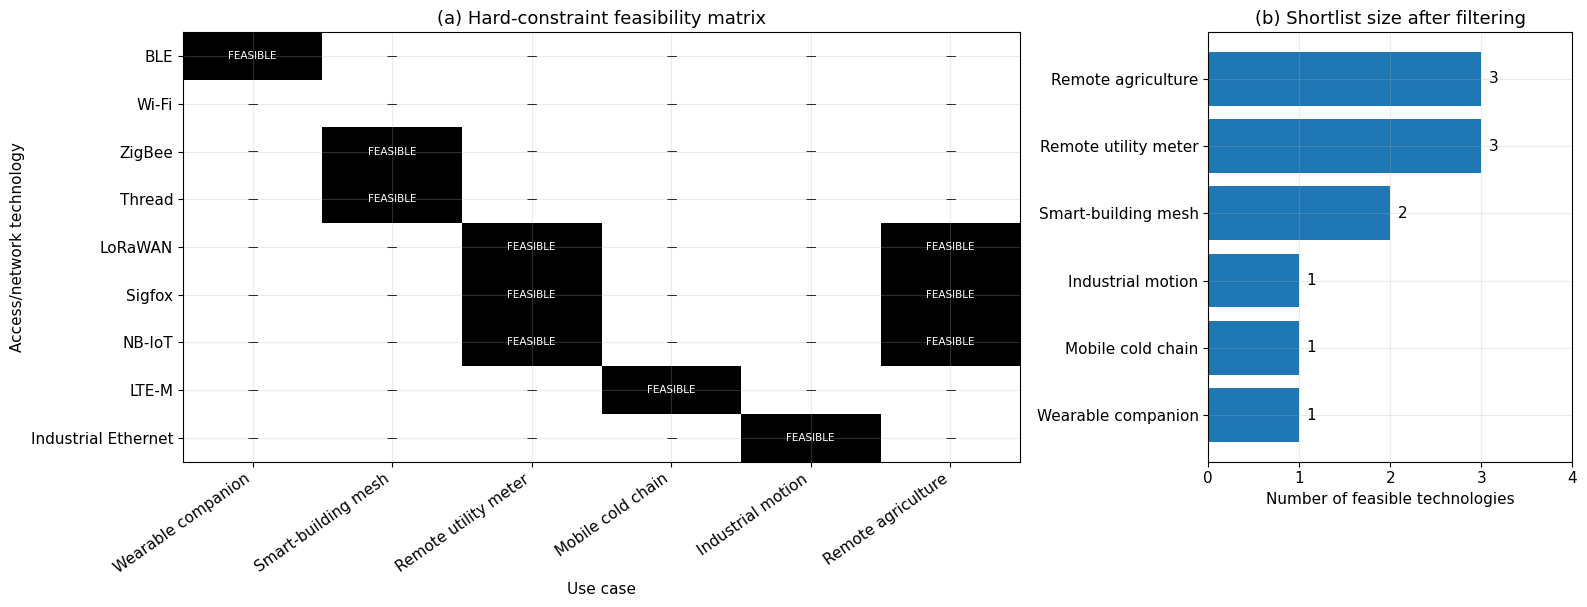

In [4]:
# ── Figure 26.1: feasibility matrix and shortlist size ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6.2), gridspec_kw={'width_ratios': [2.3, 1]})

ax = axes[0]
image = ax.imshow(feasibility.astype(int).values, aspect='auto', vmin=0, vmax=1,
                  cmap='Greys')
ax.set_xticks(range(len(feasibility.columns)))
ax.set_xticklabels(feasibility.columns, rotation=35, ha='right')
ax.set_yticks(range(len(feasibility.index)))
ax.set_yticklabels(feasibility.index)
ax.set_title('(a) Hard-constraint feasibility matrix')
ax.set_xlabel('Use case')
ax.set_ylabel('Access/network technology')
for i in range(feasibility.shape[0]):
    for j in range(feasibility.shape[1]):
        ax.text(j, i, 'FEASIBLE' if feasibility.iloc[i, j] else '—',
                ha='center', va='center', fontsize=7.5,
                color='white' if feasibility.iloc[i, j] else 'black')

ax = axes[1]
counts = feasibility.sum(axis=0).sort_values()
ax.barh(counts.index, counts.values)
ax.set_xlabel('Number of feasible technologies')
ax.set_title('(b) Shortlist size after filtering')
ax.set_xlim(0, max(counts.max() + 0.6, 4))
for y, value in enumerate(counts.values):
    ax.text(value + 0.08, y, str(int(value)), va='center')

plt.tight_layout()
save_figure('fig_26_1_feasibility.png')
plt.show()


### Analysis

The filter produces narrow, interpretable shortlists. The wearable case admits
BLE because smartphone interoperability and battery suitability are mandatory;
Wi-Fi fails the battery-class requirement. The smart-building case admits
ZigBee and Thread because mesh operation is mandatory. Wide-area, low-rate,
low-power metering admits LoRaWAN, Sigfox, and NB-IoT, whereas continuous
mobility plus a higher rate class leaves LTE-M as the only candidate in this
simplified catalogue. Deterministic industrial motion leaves industrial
Ethernet.

The point is not that every real deployment will produce the same shortlist.
The point is that the elimination reasons are explicit and auditable. A project
team can change one requirement, rerun the cell, and see exactly which options
enter or leave the feasible set. Weighted scoring belongs only *after* this
stage; otherwise a high score on cost or convenience can incorrectly compensate
for failing a non-negotiable safety, mobility, latency, or ownership constraint.

### Challenge tasks

1. Add a `public_operator_required` field and distinguish private LoRaWAN from
   operator-managed cellular connectivity.
2. Replace the five-level throughput class with a numerical minimum data rate,
   using values from a specific standard or device profile. Document the
   operating mode associated with every value.
3. Add Wi-Fi HaLow and BLE Mesh. Which use cases change, and which additional
   constraints are needed to avoid over-generalising their capabilities?
4. Add security lifecycle requirements: secure boot, remotely managed keys,
   patch delivery, and device identity. Treat them as hard constraints rather
   than as optional score bonuses.

---
## Exercise 26.2 — Robust MCDA: When the “Best” Protocol Depends on Uncertain Weights

### Background

After infeasible technologies have been removed, several candidates often
remain. A weighted score can make the trade-off explicit, but a single weight
vector creates false precision: different stakeholders rarely agree exactly on
how much energy, coverage, cost, private control, mobility, downlink capability,
or payload flexibility matters.

This exercise compares LoRaWAN, Sigfox, NB-IoT, and LTE-M for a mixed municipal
sensing workload. Seven criteria are represented by bounded utility scores in
$[0,1]$. Both the criterion weights and the technology scores are uncertain.
Weights are sampled from a Dirichlet distribution centred on a declared
baseline, while criterion scores are sampled from beta distributions centred on
the declared engineering estimates. Every Monte Carlo draw evaluates all four
technologies under the *same* sampled weight vector, so winner differences are
not caused by giving candidates different stakeholder preferences.

The result is a rank-acceptability analysis: instead of reporting only one
winner, it reports how often each technology is best across plausible
requirements and performance uncertainty.

In [5]:
# ── Exercise 26.2: uncertain scores and uncertain weights ─────────────
mcda_technologies = ['LoRaWAN', 'Sigfox', 'NB-IoT', 'LTE-M']
criteria = [
    'Energy efficiency', 'Coverage predictability', 'Downlink capability',
    'Mobility', 'Private control', 'Cost efficiency', 'Payload flexibility'
]

# Author-selected utility-score means for a mixed municipal sensing workload.
# Sigfox's local coverage and continued service are provisionally assumed
# confirmed for this comparison (Section 26.2.7's operator-viability hard
# constraint is treated as already satisfied here, not re-litigated by MCDA).
score_means = np.array([
    [0.83, 0.72, 0.62, 0.30, 0.90, 0.80, 0.62],  # LoRaWAN
    [0.90, 0.70, 0.25, 0.55, 0.15, 0.82, 0.25],  # Sigfox
    [0.78, 0.92, 0.62, 0.25, 0.20, 0.58, 0.65],  # NB-IoT
    [0.62, 0.93, 0.88, 0.96, 0.20, 0.45, 0.90],  # LTE-M
])

baseline_weights = np.array([0.22, 0.28, 0.12, 0.02, 0.08, 0.16, 0.12])
assert np.isclose(baseline_weights.sum(), 1.0)

N = 30_000
weight_concentration = 25       # lower -> greater stakeholder disagreement
score_concentration = 35        # lower -> greater performance uncertainty
mcda_rng = np.random.default_rng(SEED)

sampled_weights = mcda_rng.dirichlet(
    baseline_weights * weight_concentration, size=N
)

# Shared site-condition latent factor -- a minimal illustration of common-mode
# uncertainty, not a full environmental model. At a given deployment site,
# radio conditions (obstacles, interference, terrain) are not independent
# across technologies: a poor site tends to depress coverage AND energy
# efficiency for every candidate at once, not just one of them. Each
# technology is given its own LOADING on this shared factor rather than one
# uniform effect, because licensed cellular technologies (NB-IoT, LTE-M) sit
# on professionally planned macro networks and are less exposed to a single
# site's idiosyncrasies than unlicensed-band technologies (LoRaWAN, Sigfox)
# whose coverage depends more directly on local gateway placement. This still
# does not model technology-specific fading, penetration, or retry behaviour
# in detail, and does not attempt a full copula model -- it is a deliberately
# minimal illustration of common-mode uncertainty, not a claim of realism.
SITE_EFFECT = 0.06
site_linked_criteria = ['Energy efficiency', 'Coverage predictability']
site_linked_idx = [criteria.index(c) for c in site_linked_criteria]
site_loading = {'LoRaWAN': 1.2, 'Sigfox': 1.1, 'NB-IoT': 0.7, 'LTE-M': 0.8}


def sample_scores(local_rng, n, conc):
    """Beta-sample technology x criteria scores with the shared site factor."""
    site_factor = local_rng.normal(0.0, 1.0, size=n)
    out = np.empty((n, len(mcda_technologies), len(criteria)))
    for i, (tech, means) in enumerate(zip(mcda_technologies, score_means)):
        trial_means = np.broadcast_to(means, (n, len(criteria))).copy()
        loading = site_loading[tech]
        for c in site_linked_idx:
            trial_means[:, c] = np.clip(
                means[c] + SITE_EFFECT * loading * site_factor, 0.03, 0.97)
        alpha = trial_means * conc
        beta = (1.0 - trial_means) * conc
        out[:, i, :] = local_rng.beta(alpha, beta)
    return out


sampled_scores = sample_scores(mcda_rng, N, score_concentration)

# One common sampled weight vector per Monte Carlo draw, applied to all candidates.
total_scores = np.einsum('nc,ntc->nt', sampled_weights, sampled_scores)
winner_index = total_scores.argmax(axis=1)

mcda_summary = pd.DataFrame({
    'Technology': mcda_technologies,
    'Mean score': total_scores.mean(axis=0),
    '5th percentile': np.quantile(total_scores, 0.05, axis=0),
    '95th percentile': np.quantile(total_scores, 0.95, axis=0),
    'Rank-1 acceptability': [np.mean(winner_index == i) for i in range(len(mcda_technologies))],
})

print(mcda_summary.to_string(index=False, formatters={
    'Mean score': '{:.3f}'.format,
    '5th percentile': '{:.3f}'.format,
    '95th percentile': '{:.3f}'.format,
    'Rank-1 acceptability': '{:.1%}'.format,
}))
print()
print('"Rank-1 acceptability" is the fraction of Monte Carlo trials in which a')
print('technology attains the top score under the assumed weight and score')
print('distributions (including the shared, technology-weighted site factor')
print('above). It is a model-conditional frequency of attaining rank 1, not an')
print('empirical or posterior probability that a technology is objectively the')
print('best option in the field.')


Technology Mean score 5th percentile 95th percentile Rank-1 acceptability
   LoRaWAN      0.738          0.648           0.824                54.9%
    Sigfox      0.607          0.492           0.722                 0.5%
    NB-IoT      0.695          0.603           0.782                10.8%
     LTE-M      0.717          0.616           0.809                33.8%

"Rank-1 acceptability" is the fraction of Monte Carlo trials in which a
technology attains the top score under the assumed weight and score
distributions (including the shared, technology-weighted site factor
above). It is a model-conditional frequency of attaining rank 1, not an
empirical or posterior probability that a technology is objectively the
best option in the field.


In [6]:
# ── Exercise 26.2: two-weight sensitivity map ──────────────────────────
# Vary coverage-predictability and cost-efficiency weights. The remaining
# weight is redistributed across the other five criteria in their baseline
# proportions.
coverage_idx = criteria.index('Coverage predictability')
cost_idx = criteria.index('Cost efficiency')
other_idx = [i for i in range(len(criteria)) if i not in (coverage_idx, cost_idx)]
other_baseline = baseline_weights[other_idx]
other_baseline = other_baseline / other_baseline.sum()

grid = np.linspace(0.02, 0.55, 90)
winner_map = np.full((len(grid), len(grid)), np.nan)

for iy, w_cost in enumerate(grid):
    for ix, w_coverage in enumerate(grid):
        remainder = 1.0 - w_cost - w_coverage
        if remainder <= 0:
            continue
        w = np.zeros(len(criteria))
        w[coverage_idx] = w_coverage
        w[cost_idx] = w_cost
        w[other_idx] = remainder * other_baseline
        winner_map[iy, ix] = np.argmax(score_means @ w)


# ── Exercise 26.2: sensitivity of rank-1 acceptability to concentration ───
# weight_concentration is itself a modelling choice, not a measured quantity:
# lower values mean a wider Dirichlet spread, i.e. more assumed stakeholder
# disagreement. Re-running the same Monte Carlo procedure at three
# concentration levels shows whether the headline rank-1 figures above are a
# robust qualitative conclusion or an artefact of one parameter choice.
concentration_sweep = [10, 25, 100]
sweep_rng = np.random.default_rng(SEED)
sweep_rows = []
for w_conc in concentration_sweep:
    w = sweep_rng.dirichlet(baseline_weights * w_conc, size=N)
    s = sample_scores(sweep_rng, N, score_concentration)
    ts = np.einsum('nc,ntc->nt', w, s)
    wi = ts.argmax(axis=1)
    sweep_rows.append({
        'Weight concentration': w_conc,
        **{tech: np.mean(wi == i) for i, tech in enumerate(mcda_technologies)},
    })
sweep_summary = pd.DataFrame(sweep_rows).set_index('Weight concentration')
print('Rank-1 acceptability as weight_concentration varies')
print('(lower = more assumed stakeholder disagreement; score_concentration fixed at 35):\n')
print(sweep_summary.to_string(formatters={t: '{:.1%}'.format for t in mcda_technologies}))


Rank-1 acceptability as weight_concentration varies
(lower = more assumed stakeholder disagreement; score_concentration fixed at 35):

                     LoRaWAN Sigfox NB-IoT LTE-M
Weight concentration                            
10                     49.0%   2.4%  12.4% 36.2%
25                     55.3%   0.6%  10.6% 33.5%
100                    61.7%   0.1%   9.2% 29.0%


Saved: fig_26_2_robust_mcda.png


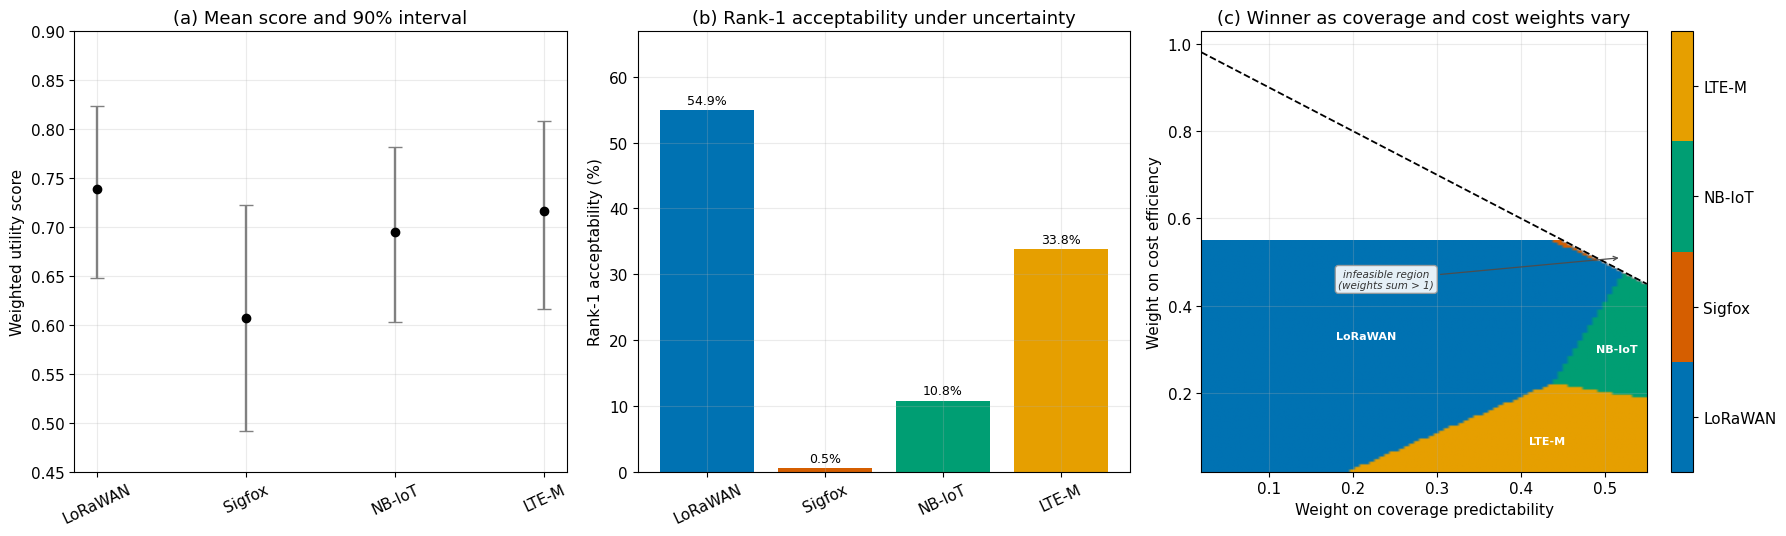

In [7]:
# ── Figure 26.2: score uncertainty, rank-1 acceptability, sensitivity ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes[0]
positions = np.arange(len(mcda_technologies))
means = total_scores.mean(axis=0)
q05 = np.quantile(total_scores, 0.05, axis=0)
q95 = np.quantile(total_scores, 0.95, axis=0)
ax.errorbar(positions, means, yerr=[means-q05, q95-means], fmt='o', capsize=5,
            color='black', ecolor='gray')
ax.set_xticks(positions)
ax.set_xticklabels(mcda_technologies, rotation=25)
ax.set_ylabel('Weighted utility score')
ax.set_title('(a) Mean score and 90% interval')
ax.set_ylim(0.45, 0.90)

ax = axes[1]
probabilities = np.array([np.mean(winner_index == i) for i in range(len(mcda_technologies))])
ax.bar(mcda_technologies, probabilities * 100, color=OKABE_ITO[:len(mcda_technologies)])
ax.set_ylabel('Rank-1 acceptability (%)')
ax.set_title('(b) Rank-1 acceptability under uncertainty')
ax.tick_params(axis='x', rotation=25)
for i, p in enumerate(probabilities):
    ax.text(i, p*100 + 1, f'{p:.1%}', ha='center', fontsize=9)
ax.set_ylim(0, max(probabilities*100) + 12)

ax = axes[2]
masked = np.ma.masked_invalid(winner_map)
cmap = ListedColormap(OKABE_ITO[:len(mcda_technologies)])
im = ax.imshow(masked, origin='lower', aspect='auto', cmap=cmap,
               extent=[grid.min(), grid.max(), grid.min(), grid.max()],
               vmin=-0.5, vmax=len(mcda_technologies)-0.5)
# Make the infeasible region (coverage weight + cost weight >= 1, leaving no
# non-negative weight for the other five criteria) explicit rather than
# leaving it as unlabelled blank space.
diag_x = np.array([grid.min(), grid.max()])
ax.plot(diag_x, 1.0 - diag_x, color='black', lw=1.3, ls='--')
ax.annotate('infeasible region\n(weights sum > 1)', xy=(0.52, 0.51), xytext=(0.24, 0.44),
            fontsize=7.5, ha='center', style='italic', color='0.2',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.6', alpha=0.9),
            arrowprops=dict(arrowstyle='->', color='0.3', lw=0.9))
ax.set_xlabel('Weight on coverage predictability')
ax.set_ylabel('Weight on cost efficiency')
ax.set_title('(c) Winner as coverage and cost weights vary')
cbar = fig.colorbar(im, ax=ax, ticks=range(len(mcda_technologies)), fraction=0.046)
cbar.ax.set_yticklabels(mcda_technologies)
# Direct text labels on the two largest contiguous winner regions, so the
# map does not rely on colour perception alone to be read correctly.
for tech_i, tech_name in enumerate(mcda_technologies):
    ys, xs = np.where(masked == tech_i)
    if len(xs) < 250:
        continue
    gx = grid[int(np.median(xs))]
    gy = grid[int(np.median(ys))]
    ax.text(gx, gy, tech_name, fontsize=8, ha='center', va='center',
            color='white', fontweight='bold')

plt.tight_layout()
save_figure('fig_26_2_robust_mcda.png')
plt.show()


### Analysis

The mean weighted score alone suggests a close decision between LoRaWAN and
LTE-M, with NB-IoT behind them and Sigfox further back for this particular
mixed workload. The rank-acceptability result is more informative: LoRaWAN and
LTE-M each win a substantial share of plausible trials, while NB-IoT wins a
smaller but non-zero region. The decision is therefore *not robust enough* to
be presented as a universal ranking.

The two-weight map explains the change. Greater emphasis on cost efficiency
can open a narrow region for Sigfox, while coverage-dominated decisions favour
NB-IoT or LTE-M; LoRaWAN remains strong where the residual weights preserve
energy efficiency and private control. Sigfox can still be attractive for a tightly bounded uplink-only service, but
its low downlink and payload-flexibility utilities keep it from winning most
of this mixed-workload parameter space.

The engineering conclusion is not “use the Monte Carlo winner.” It is to report
both the baseline decision and the conditions under which another technology
becomes preferable. That boundary is often more valuable than the winner
itself.

### Challenge tasks

1. Replace the beta score distributions with intervals derived from actual
   field measurements and vendor/service-provider quotations.
2. Add a hard minimum on downlink capability before MCDA. How does removing an
   infeasible candidate change the rank-1 acceptability figures?
3. Compare three uncertainty models side by side: (a) fully independent
   criterion uncertainty (no shared factor), (b) the common latent
   site-quality factor used above, and (c) technology-specific correlated
   factors that also link, say, coverage predictability with downlink
   capability for each technology individually. Report how much the rank-1
   acceptability figures move between the three.
4. Repeat the analysis for a mobile cold-chain tracker. Increase the mobility
   weight and explain why the winner distribution changes.


---
## Exercise 26.3 — End-to-End Stack Benchmark: Bytes, Energy, Latency, and Cost

### Background

Comparing only the radio or only the application protocol hides the cost of the
rest of the stack. This exercise defines six *technical paths*, represented by
seven accounting rows (LoRaWAN is shown once under private ownership and once
under an operator-managed subscription, since the radio is identical and only
the annual cost differs):

1. BLE from the device to a gateway, then MQTT/TLS to the cloud;
2. Thread with CoAP/OSCORE;
3. Wi-Fi with HTTPS;
4. LoRaWAN with an MQTT bridge at the network server -- private and
   operator-managed variants;
5. NB-IoT with MQTT/TLS;
6. LTE-M with MQTT/TLS.

A common accounting boundary is used: end-device energy, application/IP bytes
handed to the radio modem (not radio-interface RLC/PDCP/MAC/PHY framing or
repetitions, which this model does not estimate), end-to-end application
latency, and an annual per-device connectivity *subscription* (not full
infrastructure -- Exercise 26.4 prices that separately at fleet scale). Shared
gateway and cloud-server energy are excluded. Two session policies are
represented: **fresh**, where a connection or security context is
re-established for this report (e.g. a BLE GATT reconnection with
encryption resumption, or a fresh TLS handshake -- never one-time
pairing/bonding, which happens once per device lifetime, not once per
report), and **reused**, where an existing session amortises that cost to a
small residual rather than zero by default.

All numbers are declared teaching parameters, not measured protocol constants.
Their purpose is to expose which term dominates under a chosen workload. The
same equations can be populated later with laboratory measurements or vendor
figures.


In [8]:
# ── Exercise 26.3: declared end-to-end stack model ─────────────────────
# Columns, by group:
#  overhead_*_B        -- device-side upper-layer FRAMING bytes only (does
#                          NOT include the payload -- report_metrics() below
#                          adds payload_B separately, so overhead + payload
#                          together are what is "presented to the radio/link
#                          stack"). For the IP-based stacks (Wi-Fi, NB-IoT,
#                          LTE-M, Thread's CoAP/IPv6) this is
#                          application/security/IP framing; for BLE and
#                          LoRaWAN, which carry native non-IP payloads at
#                          this layer, it is their own native
#                          application/transport framing. Radio-interface
#                          RLC/PDCP/MAC/PHY bytes and repetitions are out of
#                          scope for this model.
#  fixed_mJ, per_byte_mJ      -- steady-state per-report radio energy terms.
#  sleep_mW             -- RADIO/communication-stack sleep power only (NOT
#                          MCU or sensors -- that is a separate baseline
#                          term added in projected_battery_life_years below,
#                          so the two are never double-counted).
#  setup_*_mJ, setup_latency_*_ms -- session/connection-establishment cost.
#    'fresh'  = the connection or security context is re-established for
#               this report (e.g. BLE reconnection + link-layer encryption
#               resumption; a fresh TLS handshake). One-time pairing/bonding
#               is deliberately excluded from this term: bonding happens
#               once per device lifetime, not once per report.
#    'reused' = an existing connection/session is reused; setup cost is the
#               small residual cost of keeping it alive, not zero by default.
#  annual_service_USD -- marginal per-device connectivity SUBSCRIPTION only
#                          (not gateway/AP/controller/backhaul infrastructure,
#                          which is captured in ownership below and discussed
#                          in the chapter text).
#  ownership           -- 'private' (self-owned infrastructure) or
#                          'operator' (a network operator is paid per device).
stacks = pd.DataFrame([
    ('BLE -> gateway -> MQTT/TLS',            18,  18, 1.2, 0.010, 0.35, 0.03, 0.012,   45,  22,   2, 0.0, 'private'),
    ('Thread + CoAP/OSCORE',                  52,  52, 2.8, 0.020, 0.80, 0.20, 0.020,   85,  15,   5, 0.0, 'private'),
    ('Wi-Fi + HTTPS',                        180, 720, 8.0, 0.015,90.00, 4.50, 0.080,   60, 120,  10, 0.0, 'private'),
    ('LoRaWAN (private) -> MQTT bridge',      21,  21,20.0, 0.750, 0.00, 0.00, 0.018, 1200,   0,   0, 0.0, 'private'),
    ('LoRaWAN (operator-managed) -> MQTT bridge', 21, 21,20.0, 0.750, 0.00, 0.00, 0.018, 1200,   0,   0, 3.0, 'operator'),
    ('NB-IoT + MQTT/TLS',                    220, 440,150., 0.120,140.0,14.00, 0.030, 1800, 900, 180, 7.2, 'operator'),
    ('LTE-M + MQTT/TLS',                     220, 440,95.0, 0.100,100.0,10.00, 0.040,  450, 500, 100, 9.6, 'operator'),
], columns=[
    'stack', 'overhead_reused_B', 'overhead_fresh_B', 'fixed_mJ',
    'per_byte_mJ', 'setup_fresh_mJ', 'setup_reused_mJ', 'sleep_mW',
    'base_latency_ms', 'setup_latency_fresh_ms', 'setup_latency_reused_ms',
    'annual_service_USD', 'ownership',
]).set_index('stack')


def report_metrics(row, payload_B, policy='reused'):
    if policy not in {'fresh', 'reused'}:
        raise ValueError("policy must be 'fresh' or 'reused'")
    overhead = row[f'overhead_{policy}_B']
    setup_energy = row[f'setup_{policy}_mJ']
    setup_latency = row[f'setup_latency_{policy}_ms']
    transmitted_B = payload_B + overhead
    energy_mJ = row['fixed_mJ'] + row['per_byte_mJ'] * transmitted_B + setup_energy
    latency_ms = row['base_latency_ms'] + setup_latency
    return transmitted_B, energy_mJ, latency_ms


def projected_battery_life_years(row, payload_B, report_interval_s,
                                  policy='reused', battery_mAh=2400,
                                  voltage_V=3.6, usable_fraction=0.80,
                                  self_discharge_pct_per_year=2.0,
                                  baseline_mcu_sensor_uA=3.0,
                                  retry_energy_margin=0.10,
                                  calendar_life_cap_years=10.0):
    """Return (energy_limited_years, deployment_planning_years).

    Boundary note: 'sleep_mW' (a column of `stacks`, above) is RADIO/
    communication-stack sleep power only. The MCU and sensor baseline draw
    below is a SEPARATE, ADDITIONAL term -- the two are never the same
    current, so there is no double-counting between them.

    energy_limited_years divides usable battery energy by average daily
    consumption from the modelled radio terms ONLY (sleep power plus
    per-report energy) -- the number a naive "energy budget" analysis
    produces when it looks only at the radio. It is a genuine upper bound,
    not a realistic estimate.

    deployment_planning_years starts from the same radio terms, then
    ADDITIONALLY charges self-discharge, a fixed MCU/sensor baseline
    current, and a retry-energy margin for failed transmissions -- all
    three omitted from energy_limited_years above -- and is finally
    hard-capped at calendar_life_cap_years. This cap is a TEACHING-MODEL
    PARAMETER, not a derived property of any real component catalogue (this
    exercise has none): a real deployment must derive its own limit from
    the selected battery, sensor, enclosure, maintenance policy, operating
    environment, and vendor support period. All parameters here are
    declared teaching assumptions, not measured or standard-defined values.
    """
    battery_J = battery_mAh/1000 * voltage_V * 3600 * usable_fraction
    _, report_mJ, _ = report_metrics(row, payload_B, policy)
    reports_per_day = 86400 / report_interval_s

    sleep_J_per_day = row['sleep_mW'] * 1e-3 * 86400
    report_J_per_day = report_mJ * 1e-3 * reports_per_day

    # Naive, radio-only budget (what an "energy budget alone" analysis does).
    naive_daily_J = sleep_J_per_day + report_J_per_day
    energy_limited_years = battery_J / naive_daily_J / 365

    # Richer budget: radio terms plus self-discharge, MCU/sensor baseline
    # draw, and a retry-energy margin -- then capped at calendar/support life.
    report_J_per_day_with_retries = report_J_per_day * (1.0 + retry_energy_margin)
    mcu_sensor_J_per_day = baseline_mcu_sensor_uA * 1e-6 * voltage_V * 86400
    self_discharge_J_per_day = battery_J * (self_discharge_pct_per_year / 100) / 365
    planning_daily_J = (sleep_J_per_day + report_J_per_day_with_retries
                         + mcu_sensor_J_per_day + self_discharge_J_per_day)
    planning_energy_years = battery_J / planning_daily_J / 365
    deployment_planning_years = min(planning_energy_years, calendar_life_cap_years)
    return energy_limited_years, deployment_planning_years


payload_B = 24
interval_s = 15 * 60
rows = []
for name, row in stacks.iterrows():
    bytes_reused, energy_reused, latency_reused = report_metrics(row, payload_B, 'reused')
    bytes_fresh, energy_fresh, latency_fresh = report_metrics(row, payload_B, 'fresh')
    energy_limited, planning_life = projected_battery_life_years(row, payload_B, interval_s)
    rows.append({
        'Stack': name,
        'Upper-layer bytes/report (reused)': bytes_reused,
        'Energy mJ (reused)': energy_reused,
        'Energy mJ (fresh)': energy_fresh,
        'Latency ms (reused)': latency_reused,
        'Energy-limited life (yr)': energy_limited,
        'Planning life, capped (yr)': planning_life,
        'Ownership': row['ownership'],
        'Annual service (USD)': row['annual_service_USD'],
    })
benchmark = pd.DataFrame(rows)
print('Workload: 24-byte payload every 15 minutes; 2400 mAh, 3.6 V battery; 80% usable energy.')
print('"Upper-layer bytes" are device-side bytes presented to the radio/link stack (application/IP')
print('for IP-based stacks, native framing for BLE and LoRaWAN); radio-interface framing and')
print('repetitions are excluded (see column note above).')
print('"Energy-limited life" is a naive radio-only budget (sleep + per-report energy, nothing else).')
print('"Planning life, capped" additionally charges self-discharge, MCU/sensor baseline draw, a')
print('retry-energy margin, and a 10-year calendar/support-life cap -- the number a deployment plan')
print('should actually use.\n')
print(benchmark.to_string(index=False, formatters={
    'Energy mJ (reused)': '{:.2f}'.format,
    'Energy mJ (fresh)': '{:.2f}'.format,
    'Energy-limited life (yr)': '{:.1f}'.format,
    'Planning life, capped (yr)': '{:.1f}'.format,
    'Annual service (USD)': '${:.2f}'.format,
}))


Workload: 24-byte payload every 15 minutes; 2400 mAh, 3.6 V battery; 80% usable energy.
"Upper-layer bytes" are device-side bytes presented to the radio/link stack (application/IP
for IP-based stacks, native framing for BLE and LoRaWAN); radio-interface framing and
repetitions are excluded (see column note above).
"Energy-limited life" is a naive radio-only budget (sleep + per-report energy, nothing else).
"Planning life, capped" additionally charges self-discharge, MCU/sensor baseline draw, a
retry-energy margin, and a 10-year calendar/support-life cap -- the number a deployment plan
should actually use.

                                    Stack  Upper-layer bytes/report (reused) Energy mJ (reused) Energy mJ (fresh)  Latency ms (reused) Energy-limited life (yr) Planning life, capped (yr) Ownership Annual service (USD)
               BLE -> gateway -> MQTT/TLS                                 42               1.65              1.97                   47                     57.0         

Saved: fig_26_3_stack_benchmark.png


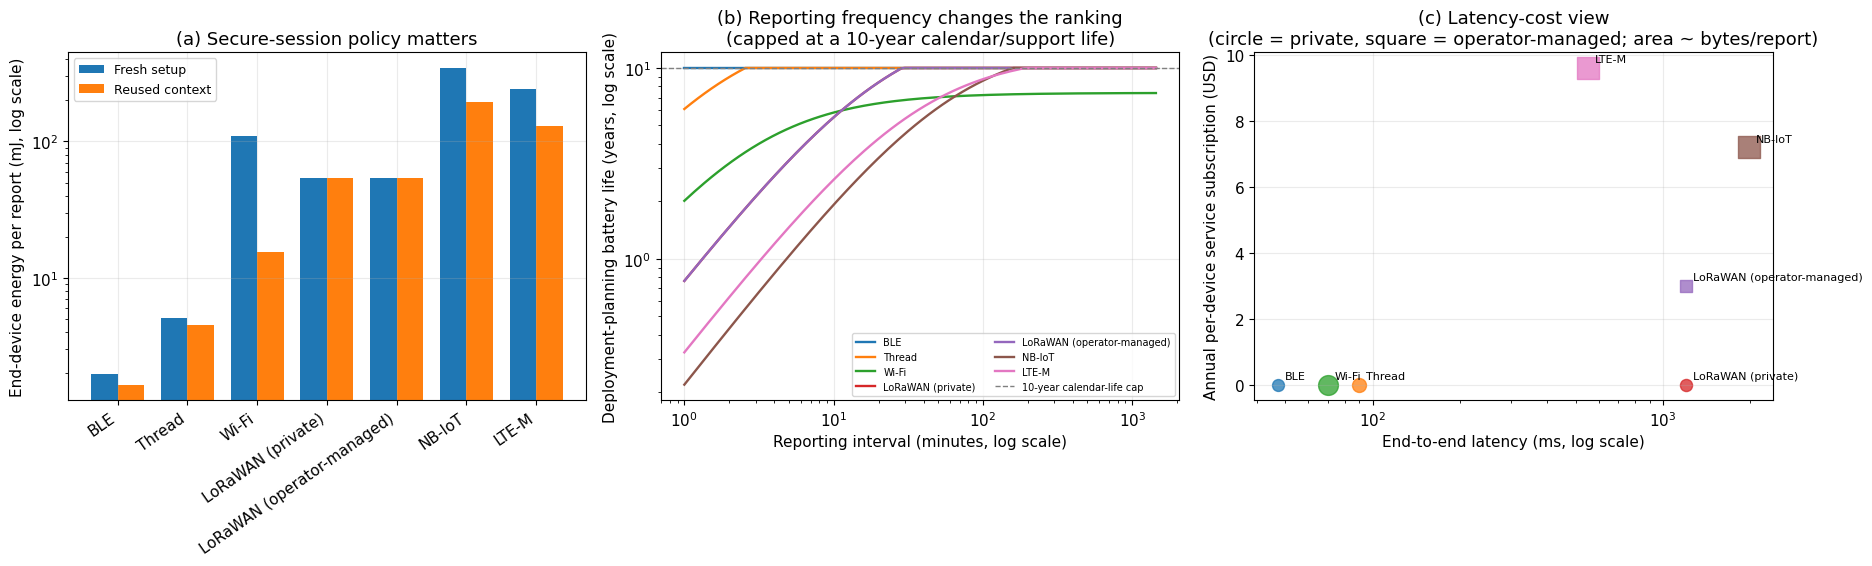

In [9]:
# ── Figure 26.3: end-to-end stack benchmark ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))

short_label = lambda name: name.split(' + ')[0].split(' -> ')[0]

# (a) Energy per 24-byte report under fresh vs reused security/session state
ax = axes[0]
x = np.arange(len(stacks))
energy_fresh = [report_metrics(row, 24, 'fresh')[1] for _, row in stacks.iterrows()]
energy_reused = [report_metrics(row, 24, 'reused')[1] for _, row in stacks.iterrows()]
width = 0.38
ax.bar(x-width/2, energy_fresh, width, label='Fresh setup')
ax.bar(x+width/2, energy_reused, width, label='Reused context')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([short_label(n) for n in stacks.index], rotation=35, ha='right')
ax.set_ylabel('End-device energy per report (mJ, log scale)')
ax.set_title('(a) Secure-session policy matters')
ax.legend()

# (b) Deployment-planning battery life vs reporting interval, reused context
ax = axes[1]
intervals_min = np.logspace(0, np.log10(24*60), 140)  # 1 minute to 1 day
for name, row in stacks.iterrows():
    life = [projected_battery_life_years(row, 24, m*60, 'reused')[1] for m in intervals_min]
    ax.plot(intervals_min, life, label=short_label(name))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Reporting interval (minutes, log scale)')
ax.set_ylabel('Deployment-planning battery life (years, log scale)')
ax.set_title('(b) Reporting frequency changes the ranking\n(capped at a 10-year calendar/support life)')
ax.axhline(10, ls='--', lw=1, color='gray', label='10-year calendar-life cap')
ax.legend(fontsize=7, ncol=2)

# (c) Latency vs annual service cost, bubble size = bytes/report
ax = axes[2]
for name, row in stacks.iterrows():
    bytes_, _, latency = report_metrics(row, 24, 'reused')
    cost = row['annual_service_USD']
    marker = 's' if row['ownership'] == 'operator' else 'o'
    ax.scatter(latency, cost, s=40 + bytes_*0.8, alpha=0.75, marker=marker)
    ax.annotate(short_label(name), (latency, cost),
                xytext=(5, 4), textcoords='offset points', fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('End-to-end latency (ms, log scale)')
ax.set_ylabel('Annual per-device service subscription (USD)')
ax.set_title('(c) Latency-cost view\n(circle = private, square = operator-managed; area ~ bytes/report)')

plt.tight_layout()
save_figure('fig_26_3_stack_benchmark.png')
plt.show()


### Analysis

Under this declared 24-byte, 15-minute workload, the BLE-to-gateway path has
the lowest end-device energy because the long-haul secure connection is paid by
the gateway rather than by the sensor. Thread/CoAP remains efficient while
preserving an IP-based mesh. Wi-Fi becomes highly sensitive to whether a secure
session is reopened for every report. LoRaWAN pays more airtime energy per
small message but retains low sleep power and incurs little protocol overhead
at the device boundary. Cellular stacks pay the largest wake-up and network
attachment costs, but LTE-M offers a materially lower latency than NB-IoT in
this model.

The battery-life curves also show why a technology ranking cannot be separated
from reporting frequency. At long intervals, sleep power (plus self-discharge
and baseline MCU/sensor draw) dominates and the capped planning-life curves
flatten at the declared 10-year calendar/support ceiling rather than climbing
indefinitely. At short intervals, per-report wake-up and setup energy
dominate. Session reuse changes Wi-Fi's result proportionally far more than
BLE's or Thread's (roughly 7x versus roughly 1.2x): all three carry a real,
non-zero fresh-connection cost, but Wi-Fi's TLS handshake is a much larger
share of its total per-report energy than BLE's or Thread's smaller
reconnection cost is of theirs.

This benchmark is intentionally not a universal performance table. It is a
reusable accounting model. Replace each row with measured parameters from the
actual chipset, signal conditions, security profile, operator plan, and gateway
boundary before making a procurement decision.

### Challenge tasks

1. Replace the declared energy parameters with measurements from two real
   development boards. Keep the same accounting boundary and report confidence
   intervals over repeated measurements.
2. Add packet loss and retries. Use one common loss trace for all stacks so that
   the comparison isolates protocol behaviour rather than random variation.
3. Add payload batching: transmit ten readings in one report. Which stacks gain
   most from amortising fixed setup and header costs?
4. Move gateway energy inside the accounting boundary for BLE and LoRaWAN.
   Compare per-device energy with total system energy at 10, 100, and 10,000
   devices.

---
## Exercise 26.4 — Hybrid Fleet Optimisation: Why One Protocol Is Often Not Enough

### Background

A heterogeneous IoT programme may contain device classes with incompatible
requirements. A smart campus, for example, can contain low-power room sensors,
mobile staff badges, outdoor utility meters, and remote pumps. Requiring one
access technology for every class simplifies procurement and operations, but
can impose large hardware and subscription costs or make some device classes
infeasible.

This exercise enumerates all feasible assignments of six technologies to four
device groups and minimises a five-year total cost of ownership (TCO). A fixed
infrastructure cost is charged once when a private technology is used; each
device then adds hardware, annual service, and maintenance cost. Feasibility is
defined before optimisation, separately per group: room sensors admit either a
local private network (Thread, Wi-Fi) or cellular coverage (NB-IoT, LTE-M) --
autonomy from a network operator is a preference weighed by cost here, not a
hard requirement; mobile badges require mobility; and the two remote/outdoor
groups require wide-area service.

The cost figures are illustrative USD parameters. They are not quotations. The
exercise compares five policies: unrestricted hybrid design, at most two
technologies, one technology for the whole fleet, private-only infrastructure,
and operator-managed connectivity only.

In [10]:
# ── Exercise 26.4: fleet, costs, and feasibility sets ───────────────────
# IMPORTANT -- different assumptions from Exercise 26.1, by design:
# this fleet's "Room sensors" group is a DIFFERENT system variant from
# Exercise 26.1's "Smart-building mesh" use case, not the same use case
# re-run. Exercise 26.1 required mandatory mesh routing (a difficult-RF
# retrofit building where mesh was the only way to reach every room), which
# is why Wi-Fi failed that use case's hard constraints. This campus fleet
# instead assumes existing managed Wi-Fi access points with sufficient
# density, so mesh routing is not a hard requirement here and Wi-Fi is a
# legitimate candidate for Room sensors. Mobile badges still exclude
# Thread/ZigBee (no mesh-radio badge hardware assumed) the same way
# Exercise 26.1 would. The lesson is general: a feasible set is only ever
# valid for the requirements that produced it -- always check which
# requirements changed before comparing feasible sets across exercises or
# across chapters.
device_groups = {
    'Room sensors': 400,
    'Mobile badges': 120,
    'Outdoor meters': 600,
    'Remote pumps': 80,
}

# NOTE ON COST BOUNDARY: 'annual_service_and_platform_USD' here is DELIBERATELY
# wider than Exercise 26.3's 'annual_service_USD' column. Exercise 26.3 prices
# a marginal per-device connectivity subscription only. This fleet-level
# figure additionally allocates network-server operation, platform support,
# and per-device administrative overhead -- costs that only appear once a
# private technology is operated at fleet scale rather than benchmarked as a
# single device. That is why private LoRaWAN shows $0.00 in Exercise 26.3 but
# a small $0.50/device/year here: same radio, a wider accounting boundary.
technology_costs = pd.DataFrame([
    # technology, fixed infrastructure, device hardware,
    # annual service+platform/device, annual maintenance/device, ownership
    ('BLE',      6000,  8,  0.0, 1.0, 'private'),
    ('Thread',   5000,  8,  0.0, 0.4, 'private'),
    ('Wi-Fi',    8000, 15,  0.0, 1.2, 'private'),
    ('LoRaWAN', 18000, 24,  0.5, 1.0, 'private'),
    ('NB-IoT',      0, 32,  9.0, 0.8, 'operator'),
    ('LTE-M',       0, 38, 12.0, 1.0, 'operator'),
], columns=[
    'technology', 'fixed_USD', 'device_USD', 'annual_service_and_platform_USD',
    'annual_maintenance_USD', 'ownership'
]).set_index('technology')

feasible_by_group = {
    'Room sensors':  ['Thread', 'Wi-Fi', 'NB-IoT', 'LTE-M'],
    'Mobile badges': ['BLE', 'Wi-Fi', 'LTE-M'],
    'Outdoor meters':['LoRaWAN', 'NB-IoT', 'LTE-M'],
    'Remote pumps':  ['LoRaWAN', 'NB-IoT', 'LTE-M'],
}

HORIZON_YEARS = 5
# Stable technology order for every set-like operation below, so that
# breakdown dictionaries and any stacked-bar plot built from them have a
# reproducible order across Python processes (a bare Python set's iteration
# order is not guaranteed to be stable run to run).
TECH_ORDER = list(technology_costs.index)


def _ordered_unique(techs):
    used = set(techs)
    return [t for t in TECH_ORDER if t in used]


def architecture_tco(assignment):
    """Five-year TCO with fixed cost charged once per technology used."""
    used = _ordered_unique(assignment.values())
    breakdown = {tech: float(technology_costs.loc[tech, 'fixed_USD']) for tech in used}
    total = sum(breakdown.values())

    for group, tech in assignment.items():
        n = device_groups[group]
        row = technology_costs.loc[tech]
        group_cost = n * (
            row['device_USD']
            + HORIZON_YEARS * (row['annual_service_and_platform_USD']
                                + row['annual_maintenance_USD'])
        )
        breakdown[tech] += group_cost
        total += group_cost
    return float(total), breakdown


def optimise_architecture(max_technologies=None, ownership=None,
                          require_single=False):
    groups = list(device_groups)
    best = None
    for values in itertools.product(*(feasible_by_group[g] for g in groups)):
        assignment = dict(zip(groups, values))
        used = _ordered_unique(values)
        if max_technologies is not None and len(used) > max_technologies:
            continue
        if require_single and len(used) != 1:
            continue
        if ownership is not None:
            if any(technology_costs.loc[t, 'ownership'] != ownership for t in used):
                continue
        total, breakdown = architecture_tco(assignment)
        if best is None or total < best['TCO']:
            best = {'TCO': total, 'assignment': assignment, 'breakdown': breakdown}
    if best is None:
        raise RuntimeError(
            'No feasible architecture found for constraints: '
            f'max_technologies={max_technologies}, ownership={ownership}, '
            f'require_single={require_single}. Check feasible_by_group and '
            'the requested constraints for a genuine contradiction before '
            'assuming this is a bug.'
        )
    return best

policies = {
    'Hybrid unrestricted': optimise_architecture(),
    'At most two technologies': optimise_architecture(max_technologies=2),
    'Single technology': optimise_architecture(require_single=True),
    'Private-only': optimise_architecture(ownership='private'),
    'Operator-only': optimise_architecture(ownership='operator'),
}

for label, result in policies.items():
    print(f'\n{label}: ${result["TCO"]:,.0f}')
    for group, tech in result['assignment'].items():
        print(f'  {group:16s} -> {tech}')

# The unrestricted optimum already uses only privately managed technologies,
# so the private-only constraint is non-binding at this optimum -- checked
# explicitly rather than left implicit:
assert policies['Hybrid unrestricted']['TCO'] == policies['Private-only']['TCO'], (
    'Expected the private-only constraint to be non-binding at the unrestricted optimum.'
)
print()
print('The private-only constraint is non-binding because the unrestricted')
print('optimum already uses only privately managed technologies for every group.')



Hybrid unrestricted: $55,980
  Room sensors     -> Thread
  Mobile badges    -> BLE
  Outdoor meters   -> LoRaWAN
  Remote pumps     -> LoRaWAN

At most two technologies: $58,340
  Room sensors     -> Wi-Fi
  Mobile badges    -> Wi-Fi
  Outdoor meters   -> LoRaWAN
  Remote pumps     -> LoRaWAN

Single technology: $123,600
  Room sensors     -> LTE-M
  Mobile badges    -> LTE-M
  Outdoor meters   -> LTE-M
  Remote pumps     -> LTE-M

Private-only: $55,980
  Room sensors     -> Thread
  Mobile badges    -> BLE
  Outdoor meters   -> LoRaWAN
  Remote pumps     -> LoRaWAN

Operator-only: $99,840
  Room sensors     -> NB-IoT
  Mobile badges    -> LTE-M
  Outdoor meters   -> NB-IoT
  Remote pumps     -> NB-IoT

The private-only constraint is non-binding because the unrestricted
optimum already uses only privately managed technologies for every group.


Saved: fig_26_4_hybrid_optimizer.png


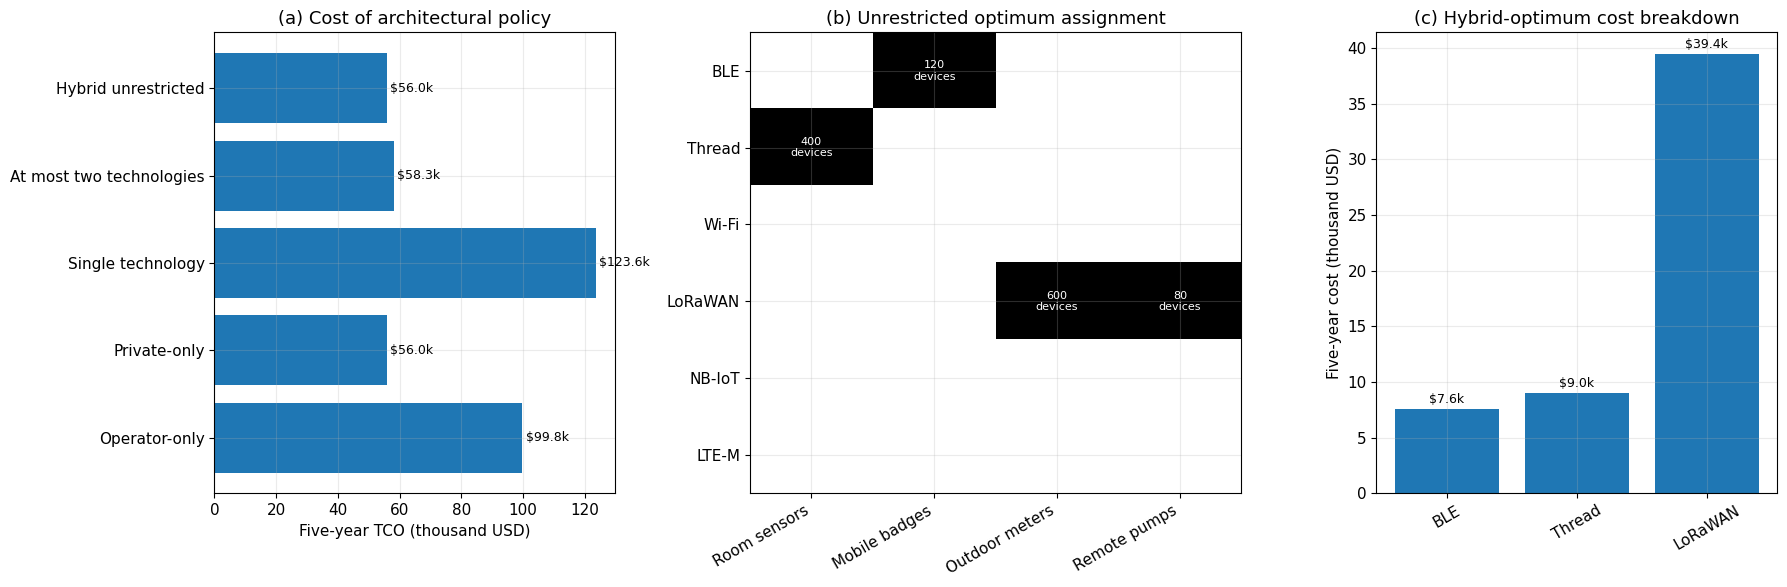

In [11]:
# ── Figure 26.4: architecture costs and assignments ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.1, 1.35, 1.1]})

# (a) policy-level TCO comparison
ax = axes[0]
labels = list(policies)
costs = [policies[label]['TCO']/1000 for label in labels]
ax.barh(labels[::-1], costs[::-1])
ax.set_xlabel('Five-year TCO (thousand USD)')
ax.set_title('(a) Cost of architectural policy')
for y, value in enumerate(costs[::-1]):
    ax.text(value + 1, y, f'${value:.1f}k', va='center', fontsize=9)

# (b) assignment matrix for the unrestricted optimum
ax = axes[1]
technologies = list(technology_costs.index)
groups = list(device_groups)
assignment = policies['Hybrid unrestricted']['assignment']
assign_matrix = np.zeros((len(technologies), len(groups)))
for j, group in enumerate(groups):
    assign_matrix[technologies.index(assignment[group]), j] = 1
ax.imshow(assign_matrix, aspect='auto', cmap='Greys', vmin=0, vmax=1)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, rotation=30, ha='right')
ax.set_yticks(range(len(technologies)))
ax.set_yticklabels(technologies)
ax.set_title('(b) Unrestricted optimum assignment')
for i in range(len(technologies)):
    for j in range(len(groups)):
        if assign_matrix[i, j]:
            ax.text(j, i, f'{device_groups[groups[j]]}\ndevices',
                    ha='center', va='center', fontsize=8, color='white')

# (c) cost breakdown by technology in the unrestricted optimum
ax = axes[2]
breakdown = policies['Hybrid unrestricted']['breakdown']
tech_used = list(breakdown)
values = [breakdown[t]/1000 for t in tech_used]
ax.bar(tech_used, values)
ax.set_ylabel('Five-year cost (thousand USD)')
ax.set_title('(c) Hybrid-optimum cost breakdown')
ax.tick_params(axis='x', rotation=30)
for i, value in enumerate(values):
    ax.text(i, value + 0.6, f'${value:.1f}k', ha='center', fontsize=9)

plt.tight_layout()
save_figure('fig_26_4_hybrid_optimizer.png')
plt.show()


### Analysis

The unrestricted optimum uses three access technologies: Thread for the room
sensors, BLE for mobile badges, and LoRaWAN for both outdoor meters and remote
pumps. The result is not a claim that these are universally best. It follows
from the declared feasibility sets and cost parameters. The important result is
structural: the optimisation pays each private infrastructure cost only where
that technology matches a distinct device class.

Restricting the design to two technologies merges room sensors and badges onto
Wi-Fi and retains LoRaWAN for remote devices. That simplification raises TCO,
but only moderately in this parameter set; an organisation may decide that the
operational benefit is worth the premium. The single-technology policy is much
more expensive because LTE-M is the only candidate declared feasible for all
four groups, so every device pays cellular hardware and service costs. The
operator-only policy is cheaper than all-LTE-M because it uses NB-IoT for fixed
sensors and LTE-M only where mobility is required, but it still exceeds the
private hybrid design.

This is the correct role of optimisation in protocol selection: it does not
replace engineering judgement. It makes the cost of architectural constraints
visible. The project team can then decide whether fewer technologies, private
ownership, operator management, or lower TCO is the dominant organisational
objective.

### Challenge tasks

1. Add a yearly gateway replacement probability and Monte Carlo uncertainty in
   installation costs. Compare expected TCO and 95th-percentile TCO.
2. Add an operational-complexity penalty for every additional technology. At
   what penalty does the two-technology design replace the unrestricted optimum?
3. Add carbon or energy cost to the objective and compute a Pareto frontier
   between financial TCO and lifecycle energy.
4. Add a fifth group of safety-critical actuators that requires deterministic
   industrial Ethernet. Explain why this requirement must be a hard feasibility
   constraint rather than a weighted preference.

---
## Practice section summary

The four exercises implement one coherent selection workflow:

1. **Separate layers and filter hard constraints.** Infeasible technologies are
   removed before any preference-based scoring.
2. **Test decision robustness.** Uncertain weights and uncertain performance
   estimates are propagated into rank-1 acceptability and decision boundaries.
3. **Benchmark complete stacks.** Bytes, energy, latency, and cost are compared
   under one explicit accounting boundary rather than mixed from unrelated
   datasheets.
4. **Optimise the whole fleet.** A heterogeneous deployment is allowed to use
   multiple technologies, and the cost of simplification is quantified.

A defensible protocol-selection report should preserve the same logic: state the
use case, define non-negotiable constraints, document assumptions and data
sources, compare only equivalent layers or complete stacks, analyse sensitivity,
and record why the final architecture was chosen.